# Assignment 14.2 - Flow Matching 2.0



## Task 14.2.1 - Flow Matching for MNIST Inpainting

* Implement a small flow matching model and training loop for an inpainting task. **(RESULT)**
* Train the flow matching model on the MNIST dataset. **(RESULT)**
* Visualize some original, masked, and inpainted images from the test set. **(RESULT)**

Hint 1: Feel free to go based on the live coding example from the lecture. <br>
Hint 2: Feel free to re-use parts of your previous implementation.
Hint 3: You can build on the provided masking preparation code below.

In [ ]:
import torch
from torchvision import datasets, transforms

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)

# Inpainting pipeline: mask right 50%
def prepare_inpainting(images):
    """Masks the right half of 28x28 MNIST images"""
    masked = images.clone()
    masked[:, :, :, 14:] = 0  # Zero out right half
    return masked, images  # (masked_input, target)

# Usage
for batch, _ in train_loader:
    masked_imgs, target_imgs = prepare_inpainting(batch)
    # masked_imgs: left half visible, right half zeros
    # target_imgs: full original images
    break

Epoch 1, Loss: 0.2712
Epoch 2, Loss: 0.1740
Epoch 3, Loss: 0.1590
Epoch 4, Loss: 0.1518
Epoch 5, Loss: 0.1454


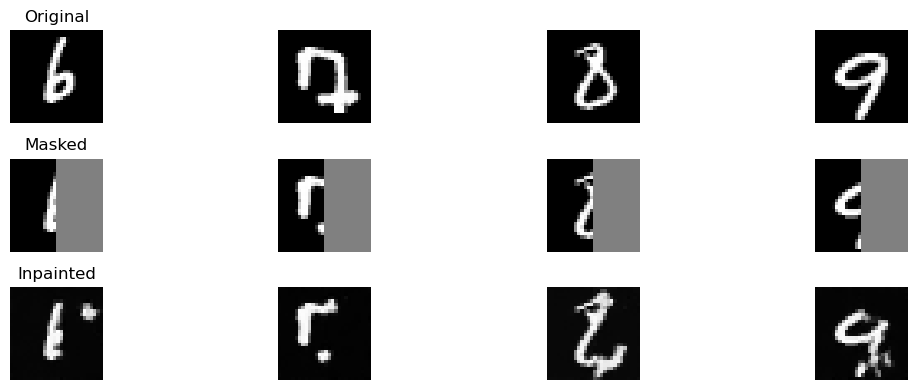

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FlowMatchingModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: x_t (1 channel) + condition (1 channel) + time (1 channel)
        # Total: 3 channels
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x_t, t, condition):
        # t shape: (B,)
        t = t.view(-1, 1, 1, 1)
        t = t.expand(-1, 1, 28, 28)
        inp = torch.cat([x_t, condition, t], dim=1)
        return self.net(inp)


model = FlowMatchingModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)
        masked_imgs, target_imgs = prepare_inpainting(images)
        masked_imgs = masked_imgs.to(device)
        target_imgs = target_imgs.to(device)

        batch_size = images.size(0)

        # x0 ~ Gaussian noise
        x0 = torch.randn_like(target_imgs)
        x1 = target_imgs

        # sample t ~ Uniform[0,1]
        t = torch.rand(batch_size, device=device)

        # linear interpolation path
        x_t = (1 - t.view(-1,1,1,1)) * x0 + t.view(-1,1,1,1) * x1

        # target velocity (constant along path)
        velocity_target = x1 - x0

        # model prediction
        velocity_pred = model(x_t, t, masked_imgs)

        loss = criterion(velocity_pred, velocity_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


model.eval()

test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=8, shuffle=True)

images, _ = next(iter(test_loader))
images = images.to(device)
masked_imgs, target_imgs = prepare_inpainting(images)
masked_imgs = masked_imgs.to(device)
target_imgs = target_imgs.to(device)

# Start from pure noise
x = torch.randn_like(target_imgs).to(device)

steps = 50
dt = 1.0 / steps

for i in range(steps):
    t = torch.ones(x.size(0), device=device) * (i / steps)
    v = model(x, t, masked_imgs)
    x = x + v * dt

generated = x.detach()

def denorm(x):
    return x * 0.5 + 0.5

plt.figure(figsize=(12,4))

for i in range(4):
    # Original
    plt.subplot(3,4,i+1)
    plt.imshow(denorm(target_imgs[i]).cpu().squeeze(), cmap='gray')
    plt.axis('off')
    if i==0:
        plt.title("Original")

    # Masked
    plt.subplot(3,4,i+5)
    plt.imshow(denorm(masked_imgs[i]).cpu().squeeze(), cmap='gray')
    plt.axis('off')
    if i==0:
        plt.title("Masked")

    # Inpainted
    plt.subplot(3,4,i+9)
    plt.imshow(denorm(generated[i]).cpu().squeeze(), cmap='gray')
    plt.axis('off')
    if i==0:
        plt.title("Inpainted")

plt.tight_layout()
plt.show()

## Task 14.2.2 - Conditional Flow Matching (BONUS)

* Using a Flow Matching model of yours, generate and visualize 10 samples for the label/number `4` of the MNIST dataset. **(RESULT)**

Hint: No Inpainting task here, just conditional generation!

Epoch 1, Loss: 0.3844
Epoch 2, Loss: 0.2533
Epoch 3, Loss: 0.2382
Epoch 4, Loss: 0.2292
Epoch 5, Loss: 0.2246


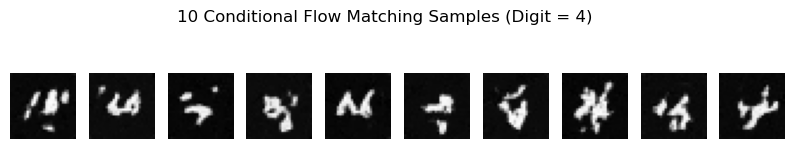

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConditionalFlowMatchingModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 28*28)

        # Input: x_t (1) + time (1) + label embedding (1)
        # Total: 3 channels
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x_t, t, labels):
        # time embedding
        t = t.view(-1,1,1,1).expand(-1,1,28,28)

        # label embedding -> reshape to image
        label_emb = self.label_emb(labels)
        label_emb = label_emb.view(-1,1,28,28)

        inp = torch.cat([x_t, t, label_emb], dim=1)
        return self.net(inp)


model = ConditionalFlowMatchingModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        batch_size = images.size(0)

        x0 = torch.randn_like(images)
        x1 = images

        t = torch.rand(batch_size, device=device)

        x_t = (1 - t.view(-1,1,1,1)) * x0 + t.view(-1,1,1,1) * x1

        velocity_target = x1 - x0

        velocity_pred = model(x_t, t, labels)

        loss = criterion(velocity_pred, velocity_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

model.eval()

num_samples = 10
labels = torch.ones(num_samples, dtype=torch.long, device=device) * 4

x = torch.randn(num_samples, 1, 28, 28).to(device)

steps = 50
dt = 1.0 / steps

for i in range(steps):
    t = torch.ones(num_samples, device=device) * (i / steps)
    v = model(x, t, labels)
    x = x + v * dt

generated = x.detach()

def denorm(x):
    return x * 0.5 + 0.5

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(denorm(generated[i]).cpu().squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("10 Conditional Flow Matching Samples (Digit = 4)")
plt.show()